## Reciprocal Rank Fusion (RRF)

### Problema

En **búsqueda híbrida** conviven dos estrategias con puntajes que **no son comparables**:

- **Búsqueda semántica** — similitud vectorial (embeddings).
- **Full text search** — coincidencia léxica (keywords).

No puedes sumar directamente un score de coseno con un score BM25. **RRF** resuelve esto usando solo la **posición relativa** de cada documento en cada ranking.

### Fórmula

Para cada documento `d` y cada ranking `r`:

```
score(d) = Σ_r  1 / (k + rank_r(d))
```

- `rank_r(d)` es la posición de `d` en el ranking `r` (**1-indexed**: el primero es rank 1).
- `k` es una constante de suavizado; el valor habitual es **60**.
- Si `d` no aparece en un ranking, no aporta término en ese ranking.

Un documento que aparece **bien posicionado en ambos rankings** acumula más score y sube en el ranking final.

### Contrato I/O

| | |
|---|---|
| **Input** | `rankings: list[list[str]]` — lista de rankings; cada ranking es una lista ordenada de IDs de documento (mejor → peor) |
| **Output** | `list[tuple[str, float]]` — pares `(doc_id, score)` ordenados por score descendente |
| **Parámetro** | `k: int = 60` — constante de suavizado |

### Casos borde

- Documento presente en **un solo** ranking → solo suma la contribución de ese ranking.
- Ranking **vacío** → se ignora (no aporta términos).
- Todos los rankings vacíos → lista vacía.
- IDs duplicados dentro del mismo ranking → solo cuenta la **primera** aparición (posición más alta).

Implementa **`rrf_fuse`** en la siguiente celda.

In [1]:
from __future__ import annotations

from collections import defaultdict


def rrf_fuse(rankings: list[list[str]], k: int = 60) -> list[tuple[str, float]]:
    """Fusiona varios rankings con Reciprocal Rank Fusion."""
    scores: dict[str, float] = defaultdict(float)
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] += 1.0 / (k + rank)
    return sorted(scores.items(), key=lambda kv: kv[1], reverse=True)

### Ejemplo aplicado: búsqueda híbrida en planes turísticos

Consulta: **`itinerario en Paracaidismo en Flandes`**

La búsqueda semántica interpreta la intención (aventura, paracaidismo, región) y puede traer planes relacionados aunque el nombre no coincida al 100%.

La búsqueda por texto premia la coincidencia literal de palabras como `itinerario`, `Paracaidismo` y `Flandes`.

RRF combina ambos rankings: el plan que aparece **bien en los dos** (nombre exacto + contenido relevante) sube al tope del ranking fusionado.

In [2]:
# Rankings simulados para la consulta del ejemplo
ranking_semantico = [
    "paracaidismo-flandes",
    "aventura-tolima",
    "guatavita-naturaleza",
    "tatacoa-desert",
]

ranking_full_text = [
    "paracaidismo-flandes",
    "itinerario-guatavita",
    "aventura-tolima",
    "mano-gigante-tatacoa",
]

fused = rrf_fuse([ranking_semantico, ranking_full_text])

print("Ranking fusionado (RRF):")
for rank, (doc_id, score) in enumerate(fused, start=1):
    print(f"  {rank}. {doc_id:25s}  score={score:.6f}")

# --- Asserts ---
# El plan presente en ambos rankings en buena posición gana
assert fused[0][0] == "paracaidismo-flandes"

# aventura-tolima aparece en ambos (pos 2 y 3) → segundo lugar
assert fused[1][0] == "aventura-tolima"

# Ranking vacío no rompe nada
assert rrf_fuse([[], ranking_semantico]) == rrf_fuse([ranking_semantico])

# Todos vacíos → lista vacía
assert rrf_fuse([[], []]) == []

# Doc solo en un ranking sigue apareciendo
solo_semantico = rrf_fuse([ranking_semantico, []])
assert solo_semantico[0][0] == "paracaidismo-flandes"

# Score manual: rank 1 en ambos con k=60 → 2 * 1/(60+1)
expected_top_score = 2.0 / 61.0
assert abs(fused[0][1] - expected_top_score) < 1e-9

Ranking fusionado (RRF):
  1. paracaidismo-flandes       score=0.032787
  2. aventura-tolima            score=0.032002
  3. itinerario-guatavita       score=0.016129
  4. guatavita-naturaleza       score=0.015873
  5. tatacoa-desert             score=0.015625
  6. mano-gigante-tatacoa       score=0.015625


### Visualización

El gráfico muestra el **score RRF final** por documento. Cuanto más larga la barra, más evidencia acumuló ese documento a través de los rankings combinados.

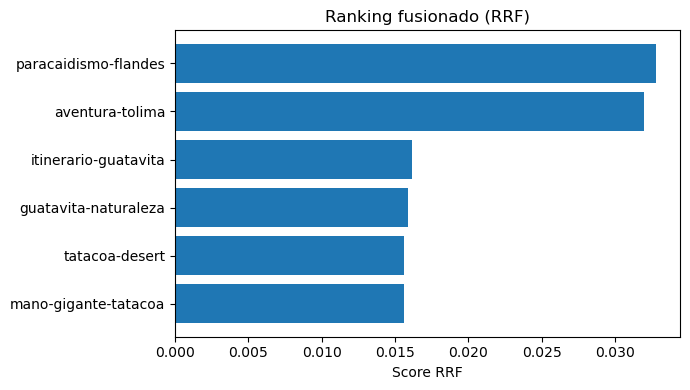

In [3]:
import matplotlib.pyplot as plt

ids = [doc_id for doc_id, _ in fused][::-1]
vals = [score for _, score in fused][::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ids, vals)
ax.set_xlabel("Score RRF")
ax.set_title("Ranking fusionado (RRF)")
plt.tight_layout()
plt.show()